Uppgift: Rena data. Bygg regressionsmodell och analysera prestanda. Vi ska säga om modellen är statistiskt signifikant.
Runt 10 variabler i ett dataset räcker att presentera, som en data-story.
10-15 minuters presentation då det är mer data att jobba mot.

Idé: Ta ett dataset för AirBnb Stockholm, rena data och bytt regressionsmodell, förslagsvis kan vi prediktera pris per natt.
Dataset: AirBnb (https://insideairbnb.com/)
listings.csv	Summary information and metrics for listings in Stockholm (good for visualisations).

In [28]:
import pandas as pd

# Bekanta oss med datasetet!

df = pd.read_csv('data/airbnb_listings_stockholm_detailed.csv')
print("5 första posterna (df.head()):")
print(df.head())

print("5 slumpmässiga poster (df.sample(5)):")
print(df.sample(5))

print("Statistik på alla numeriska kolumneriska kolumner (df.describe):")
print(df.describe())          # statistik på alla numeriska kolumner

print("Hur många observationer per område (df['neighbourhood'])")
print(df['neighbourhood'].value_counts())  # hur många i varje område

print("df.info()")
print(df.info())

5 första posterna (df.head()):
       id                          listing_url       scrape_id last_scraped  \
0  164448  https://www.airbnb.com/rooms/164448  20250929042406   2025-09-29   
1  220851  https://www.airbnb.com/rooms/220851  20250929042406   2025-09-29   
2  238411  https://www.airbnb.com/rooms/238411  20250929042406   2025-09-29   
3  242188  https://www.airbnb.com/rooms/242188  20250929042406   2025-09-29   
4  273906  https://www.airbnb.com/rooms/273906  20250929042406   2025-09-29   

        source                                         name  \
0  city scrape  Double room in central Stockholm with Wi-Fi   
1  city scrape                      One room in appartement   
2  city scrape          Cozy apartment in central Stockholm   
3  city scrape  Single room in central Stockholm with Wi-Fi   
4  city scrape               Penthouse in central Stockholm   

                                         description  \
0  I am renting out a nice double room on the top...   
1  

Rena lite data

In [29]:
# Ändra price från str till int

cleandf = df
cleandf['price'] = cleandf['price'].str.replace('$','')
cleandf['price'] = cleandf['price'].str.replace(',','')
cleandf['price'] = cleandf['price'].astype(float)




In [30]:
# Kolla priser, något är extremt högt vilket skevar analysen 112218
print(cleandf['price'].describe())

print(cleandf['price'].max())



count      3190.000000
mean       1690.473041
std        3704.741906
min         120.000000
25%         753.000000
50%        1200.000000
75%        2000.000000
max      112218.000000
Name: price, dtype: float64
112218.0


In [31]:
# Exportera till Excel för enklare granskning
import openpyxl
df.to_excel('airbnb_stockholm.xlsx', index=False)

Gör en pairplot som ska vara kung för att analysera data visuellt.

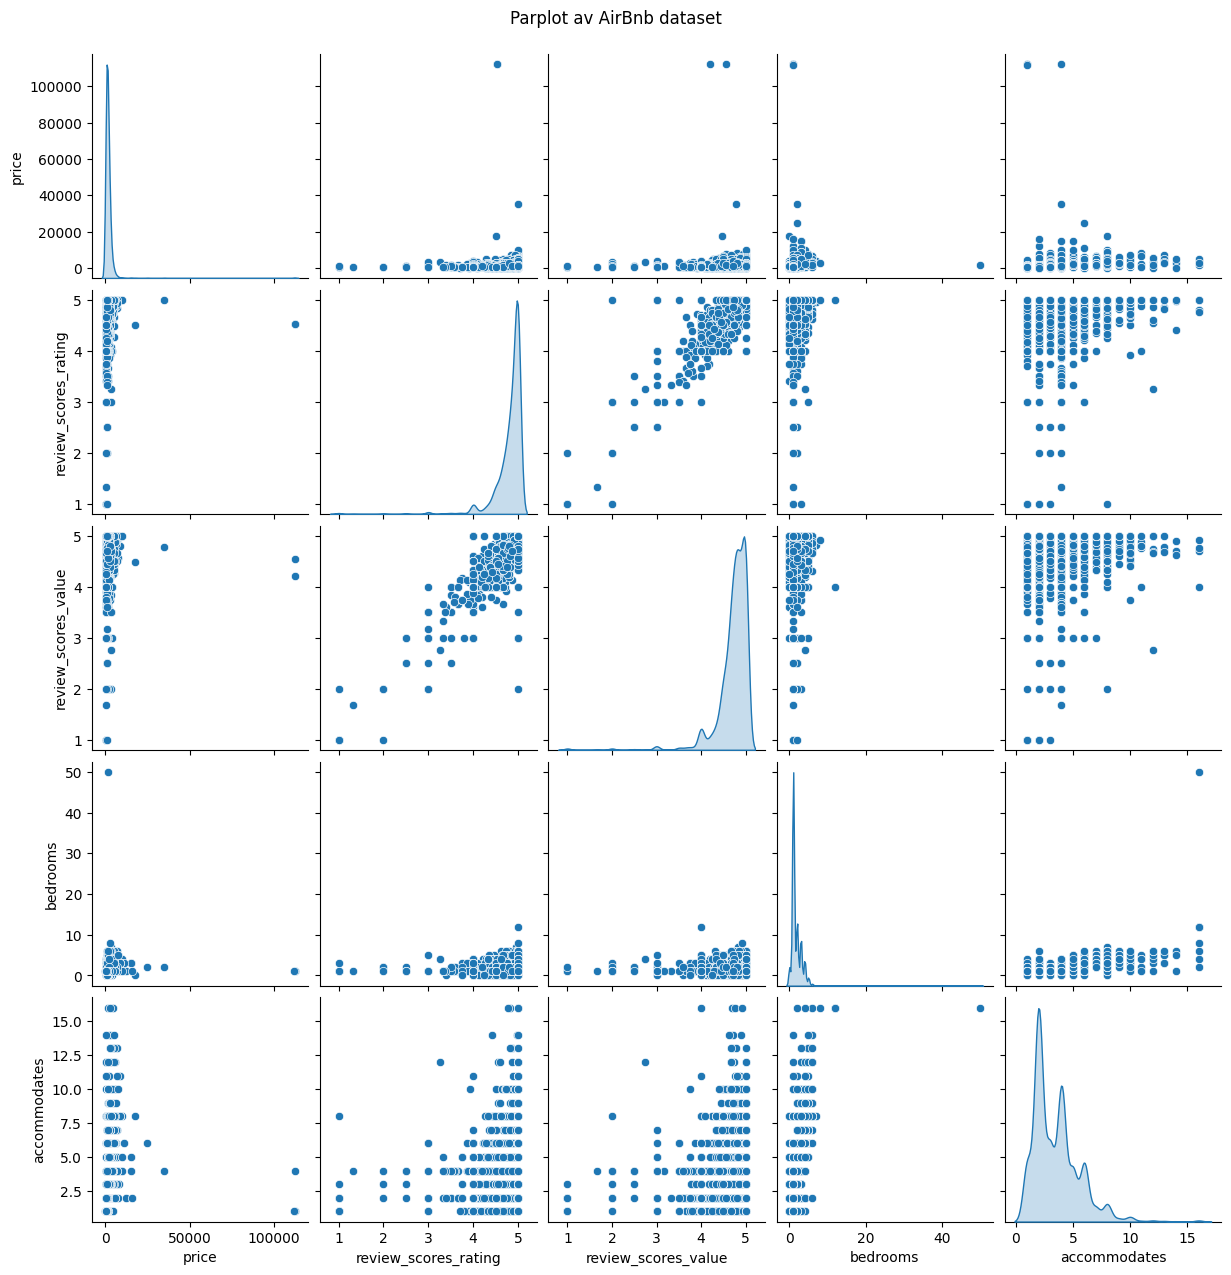

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['price','review_scores_rating','review_scores_value','room_type','bedrooms','accommodates']

pp = sns.pairplot(cleandf[cols], diag_kind='kde')
pp.figure.suptitle('Parplot av AirBnb dataset', y=1.02)

plt.show()

Datainmatningsfel i somliga fall gör att det finns extremvärden som gör att när $112,218.00 konverteras till float blir det 112218.
Vi väljer att göra percentilcapping och ha kvar värden inom 0.01 och 0.99 percentilen.

Vi upptäcker att det verkar vara datainmatningsfel på bedrooms också, någon ligger på 50 st. 50 rum motsvarar hela hotellets kapacitet.
name     room_type  property_type  bedrooms  bathrooms  \
3929  Älvsjö Stadshotell  Private room  Room in hotel      50.0       50.0   

      accommodates   price  
3929            16  1533.0  


Vi väljer att droppa alla poster som har över 20 bedrooms.


In [34]:
cleandf = cleandf[(cleandf['price'] >= cleandf['price'].quantile(0.01)) & 
              (cleandf['price'] <= cleandf['price'].quantile(0.99))] 

In [37]:
cleandf = cleandf[cleandf['bedrooms'] <= 20].copy()

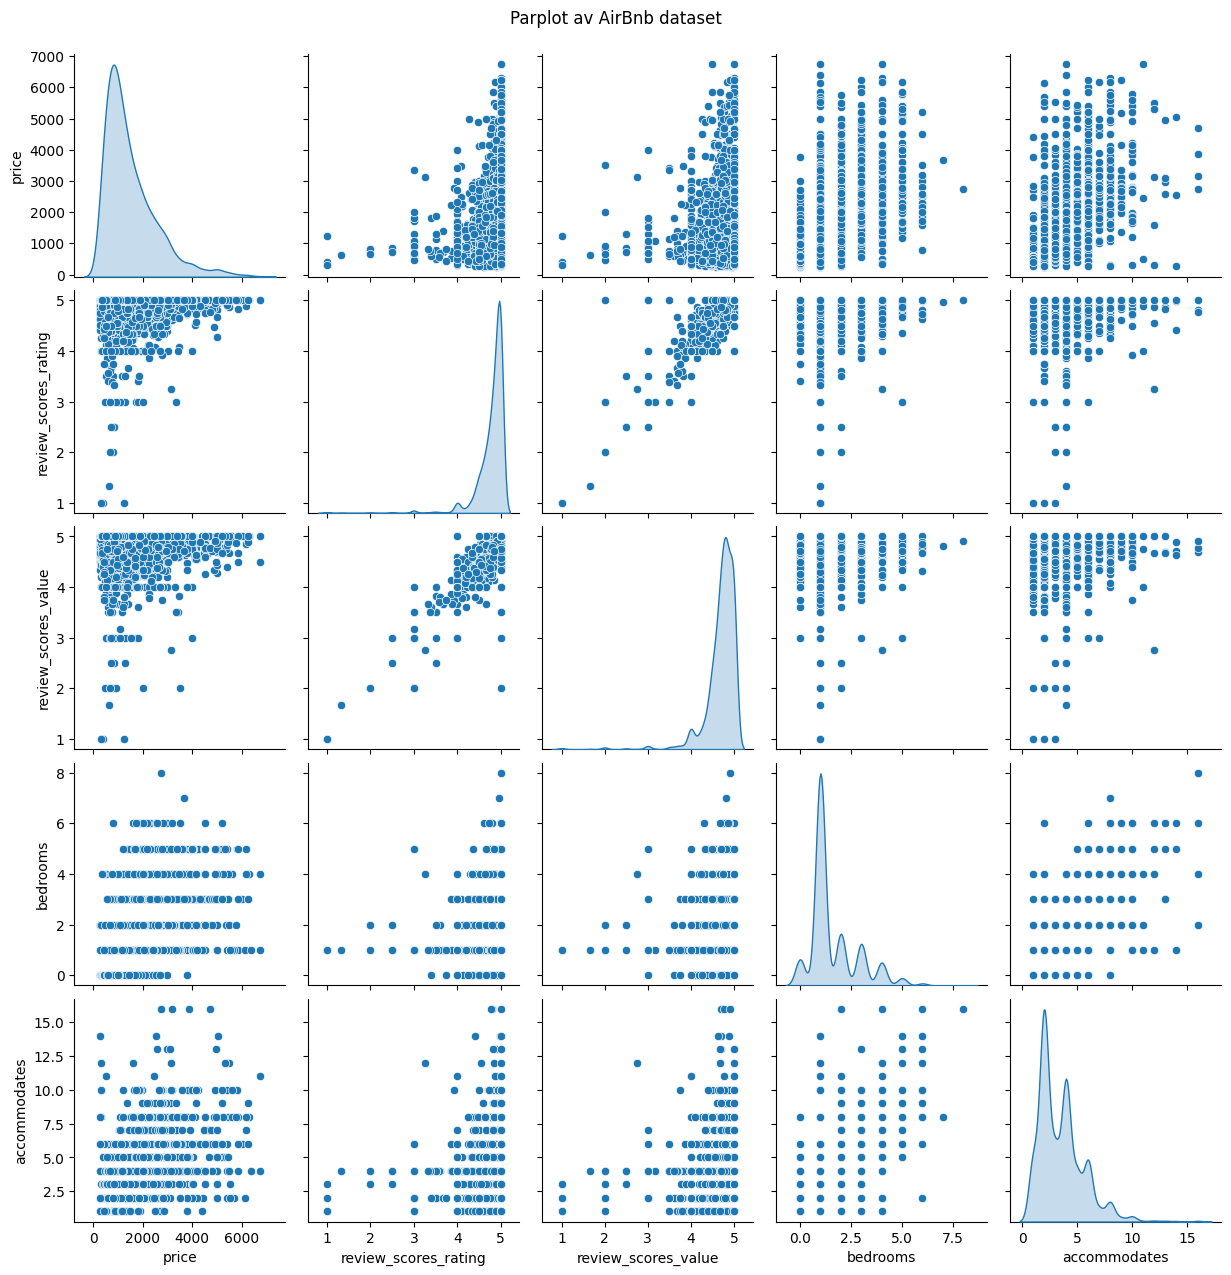

In [40]:
cols = ['price','review_scores_rating','review_scores_value','room_type','bedrooms','accommodates']

pp = sns.pairplot(cleandf[cols], diag_kind='kde')
pp.figure.suptitle('Parplot av AirBnb dataset', y=1.02)

plt.show()

In [42]:
print(cleandf[cleandf['bedrooms'] > 20][['name', 'room_type', 'property_type', 'bedrooms', 'bathrooms', 'accommodates', 'price']])

print(cleandf[cleandf['price'] > 6000][['name', 'room_type', 'property_type', 'bedrooms', 'bathrooms', 'accommodates', 'price']])


Empty DataFrame
Columns: [name, room_type, property_type, bedrooms, bathrooms, accommodates, price]
Index: []
                                                   name        room_type  \
780          Upscale cityvilla with pool, gym and sauna  Entire home/apt   
1220                           Generator - Studio Suite     Private room   
2078                   Sekelskiftesfyra vid Mariatorget     Private room   
2374                                     Bryggan Ålsten  Entire home/apt   
2572                             Eget hus på Södermalm!  Entire home/apt   
2714  Unique colorful and spacious apartment in Old ...  Entire home/apt   
3126        Luxury Yacht near City Center for 1-11 pers  Entire home/apt   
3458                    Charmigt hus i Bromma Stockholm  Entire home/apt   
3462                    Supercentral sekelskiftesvåning  Entire home/apt   

               property_type  bedrooms  bathrooms  accommodates   price  
780             Entire villa       5.0        2.5      

In [43]:
# Hur många poster ligger över rimlig USD-gräns?
print(f"Över $500/natt:  {(cleandf['price'] > 500).sum()} poster")
print(f"Över $1000/natt: {(cleandf['price'] > 1000).sum()} poster")
print(f"Över $2000/natt: {(cleandf['price'] > 2000).sum()} poster")

# Vad är medianpriset?
print(f"Median: ${cleandf['price'].median():.0f}")

Över $500/natt:  2794 poster
Över $1000/natt: 1856 poster
Över $2000/natt: 748 poster
Median: $1200
